In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))
sys.path.insert(0, str(project_root / "01_workshop"))

import numpy as np
from battery_env_solution import BatteryStorageEnv
from utils import run_episode, plot_episode, compute_energy_cost
import matplotlib.pyplot as plt

# Design a Heuristic Policy

Your goal is to control a home battery to **minimize electricity costs**.

## The Setup

Every hour, you decide whether to charge or discharge the battery:

- **Charging** stores electricity for later
- **Discharging** offsets grid purchases
- You **cannot sell** electricity back to the grid — discharge only offsets your own consumption

## Battery Specifications

| Parameter | Value |
|-----------|-------|
| Capacity | 10 kWh |
| Max charge/discharge rate | 2.5 kW |
| Efficiency | 100% (no losses) |

## What You Observe Each Hour

| Variable | Description |
|----------|-------------|
| `price` | Current electricity price (€/kWh) |
| `load` | Current household consumption (kWh) |
| `soc` | Current energy stored in the battery (kWh), 0 = empty, 10 = full |
| `hour_of_day` | Hour of the day (0–23) |
| `capacity` | Maximum battery capacity (kWh) |
| `price_max` | Maximum price in the dataset (€/kWh) — useful for setting thresholds |
| `load_max` | Maximum load in the dataset (kWh) |

## Your Action

Return a number between **-1** and **+1**:
- `+1` = charge at full power (2.5 kW)
- `-1` = discharge at full power (2.5 kW)
- `0` = do nothing

Values in between work too — e.g. `0.5` charges at half power (1.25 kW).

## Your Heuristic

Fill in the function below. Think about what you learned from the data:
- When are prices low? When are they high?
- When does the household consume the most?
- How can you use the battery to shift costs?

In [2]:
def my_heuristic(price, load, soc, hour_of_day, capacity, price_max, load_max):
    """
    Decide whether to charge or discharge the battery.

    Args:
        price (float):       Current electricity price (€/kWh)
        load (float):        Current household load (kWh)
        soc (float):         Current state of charge (kWh), between 0 and capacity
        hour_of_day (int):   Hour of the day (0-23)
        capacity (float):    Maximum battery capacity (kWh)
        price_max (float):   Maximum price in the dataset (€/kWh)
        load_max (float):    Maximum load in the dataset (kWh)

    Returns:
        action (float): A number between -1 (full discharge) and +1 (full charge)
    """
    # TODO: Design your policy 

    return 0.0 

## Run and Evaluate

The cell below plugs your heuristic into the environment and visualizes the result. Please do not change the code below (besides `SEED` if you want to test different random seeds).

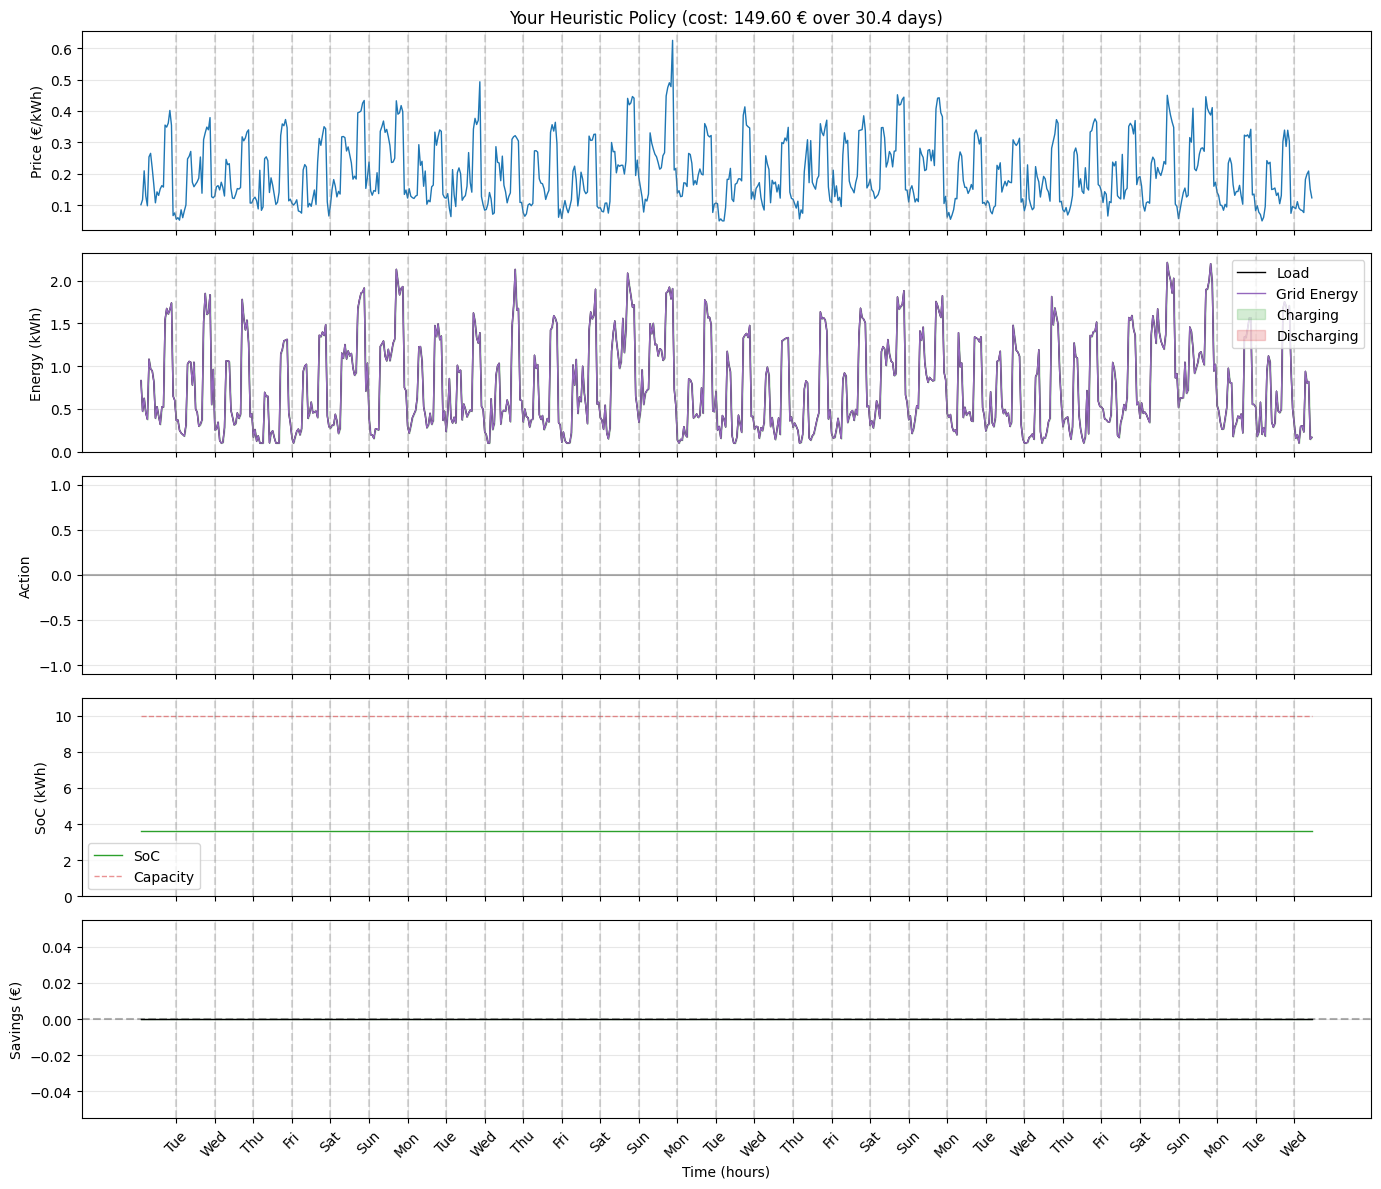

No battery:      149.60 €
Your heuristic:  149.60 €
Savings:         +0.00 € (+0.0%)


In [3]:
# Create environment (the internals are a black box for now)
EPISODE_LENGTH = 730  # hours (about one month)
SEED = 101            # change this to test different episodes
env = BatteryStorageEnv(episode_length=EPISODE_LENGTH)

# Wrap the heuristic so it works with run_episode()
def _wrap_heuristic(heuristic_fn, env):
    """Wraps a heuristic function so it works with run_episode().
    
    Args:
        heuristic_fn: A function that takes (price, load, soc, hour_of_day, capacity) and returns an action between -1 and 1.
        env: The environment instance, used to get the current info for the heuristic.

    Returns:
        A policy function that can be passed to run_episode().
    """
    def policy(obs):
        info = env._get_info()
        action = heuristic_fn(
            price=info["price"],
            load=info["load"],
            soc=info["soc"],
            hour_of_day=info["hour_of_day"],
            capacity=env.capacity,
            price_max=env.price_max,
            load_max=env.load_max,
        )
        return np.array([np.clip(action, -1, 1)], dtype=np.float32) # Ensure action is a 1D array of shape (1,) and clipped to [-1, 1]
    return policy

# Run one episode with your heuristic
policy = _wrap_heuristic(my_heuristic, env)
data, reward = run_episode(env, policy=policy, seed=SEED)

# Compare against the no-battery baseline
heuristic_cost = compute_energy_cost(data)
baseline_cost = float(np.sum(np.array(data["price"]) * np.array(data["load"])))
savings = baseline_cost - heuristic_cost

# Visualize the episode
fig = plot_episode(data, f"Your Heuristic Policy (cost: {heuristic_cost:.2f} € over {(EPISODE_LENGTH/24):.1f} days)")
plt.show()

# Print the results
print(f"No battery:      {baseline_cost:.2f} €")
print(f"Your heuristic:  {heuristic_cost:.2f} €")
print(f"Savings:         {savings:+.2f} € ({100 * savings / baseline_cost:+.1f}%)")

## Tips

What is the best policy you can up with? Here are some ideas to get you started:

- Start simple (e.g. charge at night, discharge in the evening) and iterate
- Use `hour_of_day` to target cheap/expensive hours you saw in the data
- Check `soc` before charging/discharging — don't charge a full battery or discharge an empty one
- Try different seeds (`SEED=0`, `SEED=1`, ...) to see how your heuristic performs across different episodes